In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

RANDOM_STATE = 42

shopping = pd.read_csv("/Users/surbhichauhan/Desktop/online_shoppers_intention.csv")

churn = pd.read_csv("/Users/surbhichauhan/Desktop/E-commerce company/data_ecommerce_customer_churn.csv")

print("Online Shopping shape:", shopping.shape)
print("Customer Churn shape:", churn.shape)

display(shopping.head())
display(churn.head())

Online Shopping shape: (12330, 18)
Customer Churn shape: (3941, 11)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [2]:
print("ONLINE SHOPPING DATA")
print(shopping.info())

print("\nMissing values:")
print(shopping.isnull().sum())

print("\nExact duplicates:", shopping.duplicated().sum())

print("\nRevenue distribution:")
print(shopping["Revenue"].value_counts())
print(shopping["Revenue"].value_counts(normalize=True))


print("\n\nCUSTOMER CHURN DATA")
print(churn.info())

print("\nMissing values:")
print(churn.isnull().sum())

print("\nExact duplicates:", churn.duplicated().sum())

print("\nChurn distribution:")
print(churn["Churn"].value_counts())
print(churn["Churn"].value_counts(normalize=True))

ONLINE SHOPPING DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  T

In [3]:
shopping_clean = shopping.drop_duplicates().copy()
churn_clean = churn.drop_duplicates().copy()

print("Shopping after duplicate removal:", shopping_clean.shape)
print("Churn after duplicate removal:", churn_clean.shape)

print("\nShopping class distribution:")
print(shopping_clean["Revenue"].value_counts(normalize=True))

print("\nChurn class distribution:")
print(churn_clean["Churn"].value_counts(normalize=True))

Shopping after duplicate removal: (12205, 18)
Churn after duplicate removal: (3270, 11)

Shopping class distribution:
Revenue
False    0.843671
True     0.156329
Name: proportion, dtype: float64

Churn class distribution:
Churn
0    0.836697
1    0.163303
Name: proportion, dtype: float64


In [4]:
shopping_summary = shopping_clean.groupby("Revenue")[
    [
        "PageValues",
        "ExitRates",
        "BounceRates",
        "ProductRelated",
        "ProductRelated_Duration"
    ]
].mean()

print(shopping_summary)

         PageValues  ExitRates  BounceRates  ProductRelated  \
Revenue                                                       
False      1.999985   0.045526     0.023197       29.050403   
True      27.264518   0.019555     0.005117       48.210168   

         ProductRelated_Duration  
Revenue                           
False                1082.976881  
True                 1876.209615  


In [5]:
visitor_purchase = pd.crosstab(
    shopping_clean["VisitorType"],
    shopping_clean["Revenue"],
    normalize="index"
)

print(visitor_purchase)

Revenue               False     True 
VisitorType                          
New_Visitor        0.750738  0.249262
Other              0.802469  0.197531
Returning_Visitor  0.859074  0.140926


In [6]:
churn_summary = churn_clean.groupby("Churn")[
    [
        "Tenure",
        "WarehouseToHome",
        "SatisfactionScore",
        "NumberOfAddress",
        "DaySinceLastOrder",
        "CashbackAmount"
    ]
].mean()

print(churn_summary)

          Tenure  WarehouseToHome  SatisfactionScore  NumberOfAddress  \
Churn                                                                   
0      11.488186        15.236961           2.960161         4.169225   
1       3.183128        16.989775           3.331461         4.498127   

       DaySinceLastOrder  CashbackAmount  
Churn                                     
0               4.786847      180.717007  
1               3.307540      160.513202  


In [7]:
complaint_churn = pd.crosstab(
    churn_clean["Complain"],
    churn_clean["Churn"],
    normalize="index"
)

print(complaint_churn)

Churn            0         1
Complain                    
0         0.897403  0.102597
1         0.681868  0.318132


In [8]:
shopping_target = "Revenue"

shopping_categorical = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

X_shopping = shopping_clean.drop(columns=[shopping_target])
y_shopping = shopping_clean[shopping_target].astype(int)

shopping_numeric = [
    col for col in X_shopping.columns
    if col not in shopping_categorical
]

print("Numeric features:")
print(shopping_numeric)

print("\nCategorical features:")
print(shopping_categorical)

Numeric features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

Categorical features:
['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']


In [9]:
churn_target = "Churn"

churn_categorical = [
    "PreferedOrderCat",
    "MaritalStatus",
    "Complain"
]

X_churn = churn_clean.drop(columns=[churn_target])
y_churn = churn_clean[churn_target].astype(int)

churn_numeric = [
    col for col in X_churn.columns
    if col not in churn_categorical
]

print("Numeric features:")
print(churn_numeric)

print("\nCategorical features:")
print(churn_categorical)

Numeric features:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'DaySinceLastOrder', 'CashbackAmount']

Categorical features:
['PreferedOrderCat', 'MaritalStatus', 'Complain']


In [10]:
def create_preprocessor(numeric_features, categorical_features):

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    return preprocessor

In [11]:
X_shop_train, X_shop_test, y_shop_train, y_shop_test = train_test_split(
    X_shopping,
    y_shopping,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_shopping
)

X_churn_train, X_churn_test, y_churn_train, y_churn_test = train_test_split(
    X_churn,
    y_churn,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_churn
)

print("Shopping training:", X_shop_train.shape)
print("Shopping testing:", X_shop_test.shape)

print("Churn training:", X_churn_train.shape)
print("Churn testing:", X_churn_test.shape)

Shopping training: (9764, 17)
Shopping testing: (2441, 17)
Churn training: (2616, 10)
Churn testing: (654, 10)


In [12]:
def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities)
    }

    print(model_name)
    print("=" * 50)

    print(classification_report(y_test, predictions))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    print("ROC-AUC:", results["ROC-AUC"])
    print("PR-AUC:", results["PR-AUC"])

    return results

In [13]:
shopping_preprocessor_lr = create_preprocessor(
    shopping_numeric,
    shopping_categorical
)

shopping_lr = Pipeline([
    ("preprocessor", shopping_preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

shopping_lr.fit(X_shop_train, y_shop_train)

shopping_lr_results = evaluate_model(
    shopping_lr,
    X_shop_test,
    y_shop_test,
    "Shopping - Logistic Regression"
)

Shopping - Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.86      0.90      2059
           1       0.50      0.80      0.62       382

    accuracy                           0.85      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.85      0.86      2441

Confusion Matrix:
[[1761  298]
 [  78  304]]
ROC-AUC: 0.9096572575005912
PR-AUC: 0.662707917912234


In [14]:
shopping_preprocessor_rf = create_preprocessor(
    shopping_numeric,
    shopping_categorical
)

shopping_rf = Pipeline([
    ("preprocessor", shopping_preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

shopping_rf.fit(X_shop_train, y_shop_train)

shopping_rf_results = evaluate_model(
    shopping_rf,
    X_shop_test,
    y_shop_test,
    "Shopping - Random Forest"
)

Shopping - Random Forest
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2059
           1       0.67      0.68      0.68       382

    accuracy                           0.90      2441
   macro avg       0.81      0.81      0.81      2441
weighted avg       0.90      0.90      0.90      2441

Confusion Matrix:
[[1934  125]
 [ 123  259]]
ROC-AUC: 0.9284916939804562
PR-AUC: 0.7367946696653463


In [15]:
churn_preprocessor_lr = create_preprocessor(
    churn_numeric,
    churn_categorical
)

churn_lr = Pipeline([
    ("preprocessor", churn_preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

churn_lr.fit(X_churn_train, y_churn_train)

churn_lr_results = evaluate_model(
    churn_lr,
    X_churn_test,
    y_churn_test,
    "Churn - Logistic Regression"
)

Churn - Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.76      0.86       547
           1       0.43      0.90      0.58       107

    accuracy                           0.79       654
   macro avg       0.70      0.83      0.72       654
weighted avg       0.88      0.79      0.81       654

Confusion Matrix:
[[418 129]
 [ 11  96]]
ROC-AUC: 0.9190828478190299
PR-AUC: 0.7067063905704216


In [16]:
churn_preprocessor_rf = create_preprocessor(
    churn_numeric,
    churn_categorical
)

churn_rf = Pipeline([
    ("preprocessor", churn_preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

churn_rf.fit(X_churn_train, y_churn_train)

churn_rf_results = evaluate_model(
    churn_rf,
    X_churn_test,
    y_churn_test,
    "Churn - Random Forest"
)

Churn - Random Forest
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       547
           1       0.72      0.79      0.75       107

    accuracy                           0.92       654
   macro avg       0.84      0.86      0.85       654
weighted avg       0.92      0.92      0.92       654

Confusion Matrix:
[[515  32]
 [ 23  84]]
ROC-AUC: 0.9521092108185686
PR-AUC: 0.7438357431044563


In [17]:
results_df = pd.DataFrame([
    shopping_lr_results,
    shopping_rf_results,
    churn_lr_results,
    churn_rf_results
])

results_df = results_df.round(3)

display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Shopping - Logistic Regression,0.846,0.505,0.796,0.618,0.910,0.663
1,Shopping - Random Forest,0.898,0.674,0.678,0.676,0.928,0.737
2,Churn - Logistic Regression,0.786,0.427,0.897,0.578,0.919,0.707
3,Churn - Random Forest,0.916,0.724,0.785,0.753,0.952,0.744


In [18]:
def get_feature_importance(pipeline, top_n=10):

    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["classifier"]

    feature_names = preprocessor.get_feature_names_out()
    importance = model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(
        "Importance",
        ascending=False
    )

    return importance_df.head(top_n)

In [19]:
shopping_importance = get_feature_importance(
    shopping_rf,
    top_n=10
)

display(shopping_importance)

,Feature,Importance
8,num__PageValues,0.370968
7,num__ExitRates,0.093892
5,num__ProductRelated_Duration,0.079060
4,num__ProductRelated,0.063879
6,num__BounceRates,0.052172
1,num__Administrative_Duration,0.045729
0,num__Administrative,0.039762
17,cat__Month_Nov,0.028652
3,num__Informational_Duration,0.019684
2,num__Informational,0.013817


In [20]:
churn_importance = get_feature_importance(
    churn_rf,
    top_n=10
)

display(churn_importance)

,Feature,Importance
0,num__Tenure,0.316363
6,num__CashbackAmount,0.148530
1,num__WarehouseToHome,0.083550
5,num__DaySinceLastOrder,0.069459
4,num__NumberOfAddress,0.067172
3,num__SatisfactionScore,0.063222
17,cat__Complain_1,0.047023
16,cat__Complain_0,0.046668
2,num__NumberOfDeviceRegistered,0.033390
15,cat__MaritalStatus_Single,0.025374


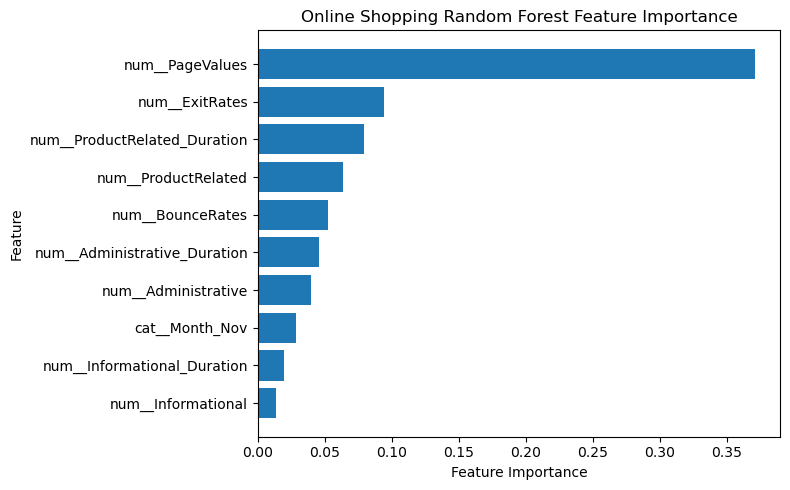

In [21]:
plt.figure(figsize=(8, 5))

plot_data = shopping_importance.sort_values("Importance")

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Online Shopping Random Forest Feature Importance")

plt.tight_layout()
plt.savefig(
    "shopping_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

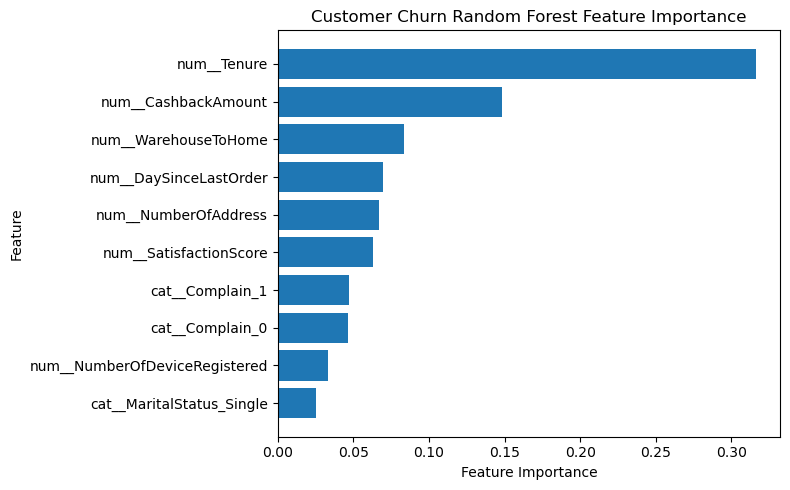

In [22]:
plt.figure(figsize=(8, 5))

plot_data = churn_importance.sort_values("Importance")

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Customer Churn Random Forest Feature Importance")

plt.tight_layout()
plt.savefig(
    "churn_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# Create results dataframe

results_df = pd.DataFrame([
    shopping_lr_results,
    shopping_rf_results,
    churn_lr_results,
    churn_rf_results
])

results_df = results_df.round(3)

display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Shopping - Logistic Regression,0.846,0.505,0.796,0.618,0.910,0.663
1,Shopping - Random Forest,0.898,0.674,0.678,0.676,0.928,0.737
2,Churn - Logistic Regression,0.786,0.427,0.897,0.578,0.919,0.707
3,Churn - Random Forest,0.916,0.724,0.785,0.753,0.952,0.744


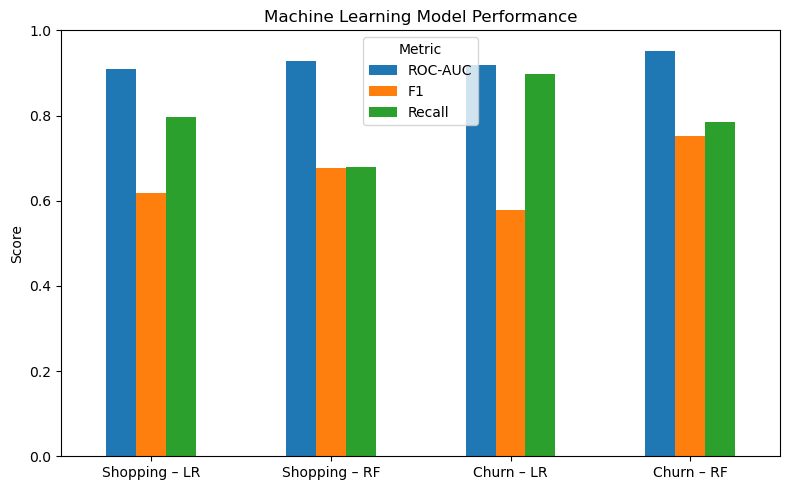

In [24]:
plot_results = results_df.copy()

plot_results["Model"] = [
    "Shopping – LR",
    "Shopping – RF",
    "Churn – LR",
    "Churn – RF"
]

plot_results = plot_results.set_index("Model")[
    ["ROC-AUC", "F1", "Recall"]
]

ax = plot_results.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Machine Learning Model Performance")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

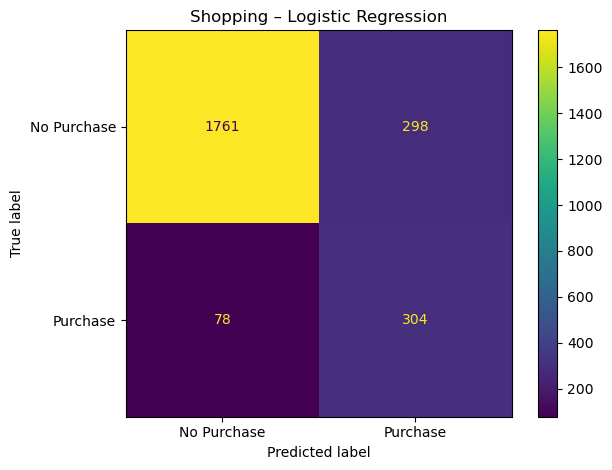

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

shopping_lr_pred = shopping_lr.predict(X_shop_test)

ConfusionMatrixDisplay.from_predictions(
    y_shop_test,
    shopping_lr_pred,
    display_labels=["No Purchase", "Purchase"],
    values_format="d"
)

plt.title("Shopping – Logistic Regression")
plt.tight_layout()

plt.savefig(
    "shopping_lr_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

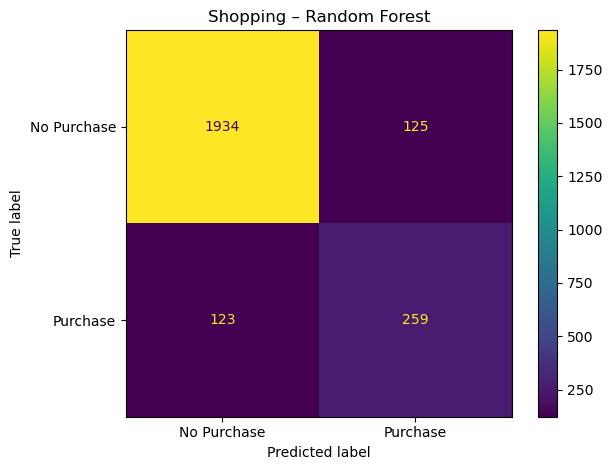

In [26]:
shopping_rf_pred = shopping_rf.predict(X_shop_test)

ConfusionMatrixDisplay.from_predictions(
    y_shop_test,
    shopping_rf_pred,
    display_labels=["No Purchase", "Purchase"],
    values_format="d"
)

plt.title("Shopping – Random Forest")
plt.tight_layout()

plt.savefig(
    "shopping_rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

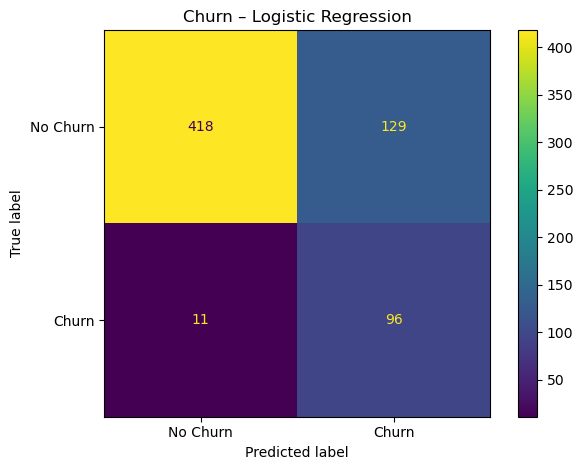

In [27]:
churn_lr_pred = churn_lr.predict(X_churn_test)

ConfusionMatrixDisplay.from_predictions(
    y_churn_test,
    churn_lr_pred,
    display_labels=["No Churn", "Churn"],
    values_format="d"
)

plt.title("Churn – Logistic Regression")
plt.tight_layout()

plt.savefig(
    "churn_lr_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

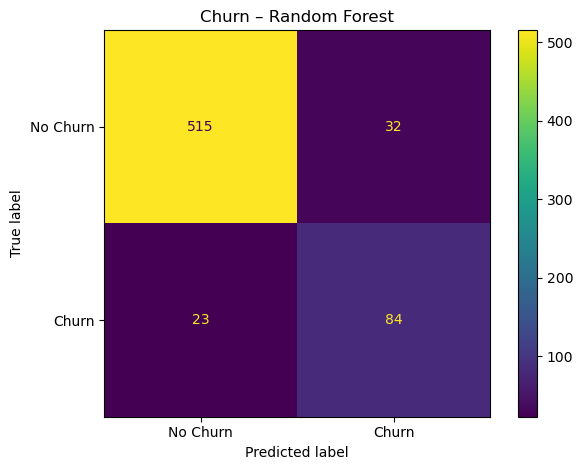

In [28]:
churn_rf_pred = churn_rf.predict(X_churn_test)

ConfusionMatrixDisplay.from_predictions(
    y_churn_test,
    churn_rf_pred,
    display_labels=["No Churn", "Churn"],
    values_format="d"
)

plt.title("Churn – Random Forest")
plt.tight_layout()

plt.savefig(
    "churn_rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

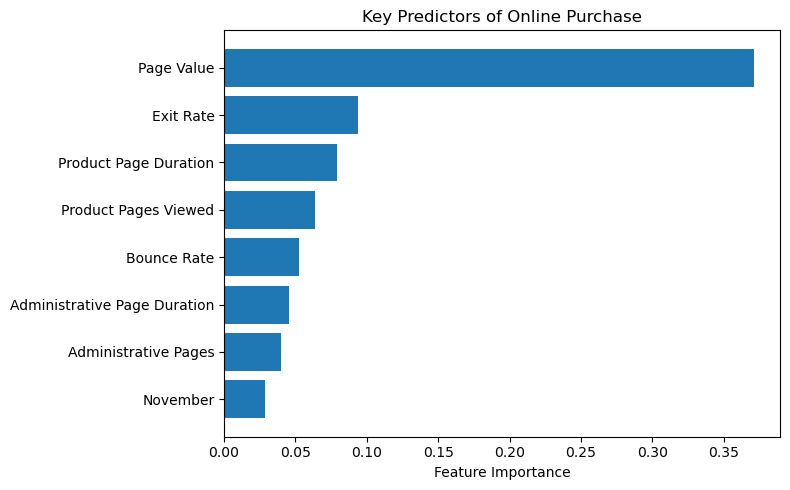

In [29]:
shopping_plot = shopping_importance.copy()

# Remove preprocessing prefixes
shopping_plot["Feature"] = (
    shopping_plot["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Rename features for readability
feature_names = {
    "PageValues": "Page Value",
    "ExitRates": "Exit Rate",
    "ProductRelated_Duration": "Product Page Duration",
    "ProductRelated": "Product Pages Viewed",
    "BounceRates": "Bounce Rate",
    "Administrative_Duration": "Administrative Page Duration",
    "Administrative": "Administrative Pages",
    "Month_Nov": "November"
}

shopping_plot["Feature"] = shopping_plot["Feature"].replace(feature_names)

# Select the top 8 features
plot_data = shopping_plot.head(8).sort_values("Importance")

# Plot
plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("")
plt.title("Key Predictors of Online Purchase")

plt.tight_layout()

plt.savefig(
    "shopping_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

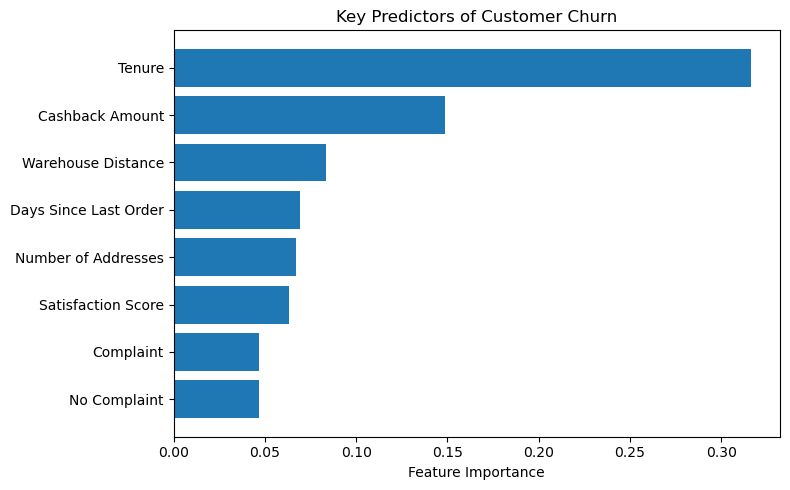

In [30]:
churn_plot = churn_importance.copy()

churn_plot["Feature"] = (
    churn_plot["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_names = {
    "Tenure": "Tenure",
    "CashbackAmount": "Cashback Amount",
    "WarehouseToHome": "Warehouse Distance",
    "DaySinceLastOrder": "Days Since Last Order",
    "NumberOfAddress": "Number of Addresses",
    "SatisfactionScore": "Satisfaction Score",
    "Complain_1": "Complaint",
    "Complain_0": "No Complaint",
    "NumberOfDeviceRegistered": "Devices Registered",
    "MaritalStatus_Single": "Single"
}

churn_plot["Feature"] = churn_plot["Feature"].replace(feature_names)

plot_data = churn_plot.head(8).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("")
plt.title("Key Predictors of Customer Churn")

plt.tight_layout()

plt.savefig(
    "churn_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
import os

print(os.getcwd())

/Users/surbhichauhan/Desktop


In [32]:
print([
    file for file in os.listdir()
    if file.endswith(".png")
])

['shopping_feature_importance.png', 'Screenshot 2026-09-19 at 11.12.03\u202fAM.png', 'ChatGPT Image May 6, 2026, 05_30_39 PM.png', 'Screenshot 2026-06-04 at 1.38.42\u202fPM.png', 'Screenshot 2026-05-02 at 11.26.18\u202fPM.png', '.Screenshot 2026-09-19 at 11.32.06\u202fAM.png', 'ChatGPT Image Jul 25, 2026, 08_25_15 PM.png', 'logo (1).png', 'Screenshot 2026-05-21 at 10.54.09\u202fPM.png', 'Screenshot 2026-05-01 at 10.27.14\u202fPM.png', 'diagram_pro.png', 'Screenshot 2026-05-01 at 9.33.17\u202fPM.png', 'shopping_lr_confusion_matrix.png', 'Screenshot 2026-05-21 at 12.26.14\u202fAM.png', 'churn_rf_confusion_matrix.png', 'Screenshot 2026-06-04 at 5.45.26\u202fPM.png', 'background.png', 'Screenshot 2026-05-28 at 1.09.24\u202fPM.png', 'Screenshot 2026-05-29 at 10.28.15\u202fAM.png', 'logo 5.png', 'logo 4.png', 'Screenshot 2026-09-19 at 8.47.58\u202fAM.png', 'Screenshot 2026-09-19 at 2.17.06\u202fPM.png', 'logo.png', 'churn_feature_importance.png', 'ai model.png', 'logo 3.png', 'logo 2.png', '

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# PART 2.1 - STRATIFIED CROSS-VALIDATION
# ---------------------------------------------------------

# Fixed random state for reproducibility
RANDOM_STATE = 42

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}


def run_cross_validation(model, X, y, model_name):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    result = {
        "Model": model_name,
        "F1 Mean": scores["test_f1"].mean(),
        "F1 SD": scores["test_f1"].std(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC SD": scores["test_roc_auc"].std(),
        "PR-AUC Mean": scores["test_pr_auc"].mean(),
        "PR-AUC SD": scores["test_pr_auc"].std()
    }

    return result

print("Cross-validation setup complete.")

Cross-validation setup complete.


In [34]:
cv_results = []

cv_results.append(
    run_cross_validation(
        shopping_lr,
        X_shopping,
        y_shopping,
        "Shopping - Logistic Regression"
    )
)

cv_results.append(
    run_cross_validation(
        shopping_rf,
        X_shopping,
        y_shopping,
        "Shopping - Random Forest"
    )
)

cv_results.append(
    run_cross_validation(
        churn_lr,
        X_churn,
        y_churn,
        "Churn - Logistic Regression"
    )
)

cv_results.append(
    run_cross_validation(
        churn_rf,
        X_churn,
        y_churn,
        "Churn - Random Forest"
    )
)

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df.round(3))

,Model,F1 Mean,F1 SD,ROC-AUC Mean,ROC-AUC SD,PR-AUC Mean,PR-AUC SD
0,Shopping - Logistic Regression,0.607,0.019,0.902,0.007,0.651,0.010
1,Shopping - Random Forest,0.679,0.006,0.930,0.009,0.743,0.018
2,Churn - Logistic Regression,0.563,0.015,0.881,0.011,0.667,0.023
3,Churn - Random Forest,0.712,0.038,0.939,0.012,0.777,0.028


In [35]:
# Check variables currently available in the notebook
[name for name in globals() if any(
    word in name.lower()
    for word in ["shopping", "churn", "model", "pipe", "lr", "rf"]
)]

['Pipeline',
 'shopping',
 'churn',
 'shopping_clean',
 'churn_clean',
 'shopping_summary',
 'churn_summary',
 'complaint_churn',
 'shopping_target',
 'shopping_categorical',
 'X_shopping',
 'y_shopping',
 'shopping_numeric',
 'churn_target',
 'churn_categorical',
 'X_churn',
 'y_churn',
 'churn_numeric',
 'X_churn_train',
 'X_churn_test',
 'y_churn_train',
 'y_churn_test',
 'evaluate_model',
 'shopping_preprocessor_lr',
 'shopping_lr',
 'shopping_lr_results',
 'shopping_preprocessor_rf',
 'shopping_rf',
 'shopping_rf_results',
 'churn_preprocessor_lr',
 'churn_lr',
 'churn_lr_results',
 'churn_preprocessor_rf',
 'churn_rf',
 'churn_rf_results',
 'shopping_importance',
 'churn_importance',
 'shopping_lr_pred',
 'shopping_rf_pred',
 'churn_lr_pred',
 'churn_rf_pred',
 'shopping_plot',
 'churn_plot']

In [74]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# PART 2.2 - LEARNING CURVE ANALYSIS
# ---------------------------------------------------------

train_sizes = np.linspace(0.1, 1.0, 6)


def calculate_learning_curve(model, X, y):

    sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring="f1",
        shuffle=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    return {
        "sizes": sizes,
        "train_mean": train_scores.mean(axis=1),
        "train_sd": train_scores.std(axis=1),
        "validation_mean": validation_scores.mean(axis=1),
        "validation_sd": validation_scores.std(axis=1)
    }


shopping_lr_curve = calculate_learning_curve(
    shopping_lr,
    X_shopping,
    y_shopping
)

shopping_rf_curve = calculate_learning_curve(
    shopping_rf,
    X_shopping,
    y_shopping
)

churn_lr_curve = calculate_learning_curve(
    churn_lr,
    X_churn,
    y_churn
)

churn_rf_curve = calculate_learning_curve(
    churn_rf,
    X_churn,
    y_churn
)

print("Learning curves calculated successfully.")

Learning curves calculated successfully.


In [76]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# PART 2.2 - LEARNING CURVE ANALYSIS
# ---------------------------------------------------------

train_sizes = np.linspace(0.1, 1.0, 6)


def calculate_learning_curve(model, X, y):

    sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring="f1",
        shuffle=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    return {
        "sizes": sizes,
        "train_mean": train_scores.mean(axis=1),
        "train_sd": train_scores.std(axis=1),
        "validation_mean": validation_scores.mean(axis=1),
        "validation_sd": validation_scores.std(axis=1)
    }


shopping_lr_curve = calculate_learning_curve(
    shopping_lr,
    X_shopping,
    y_shopping
)

shopping_rf_curve = calculate_learning_curve(
    shopping_rf,
    X_shopping,
    y_shopping
)

churn_lr_curve = calculate_learning_curve(
    churn_lr,
    X_churn,
    y_churn
)

churn_rf_curve = calculate_learning_curve(
    churn_rf,
    X_churn,
    y_churn
)

print("Learning curves calculated successfully.")

Learning curves calculated successfully.


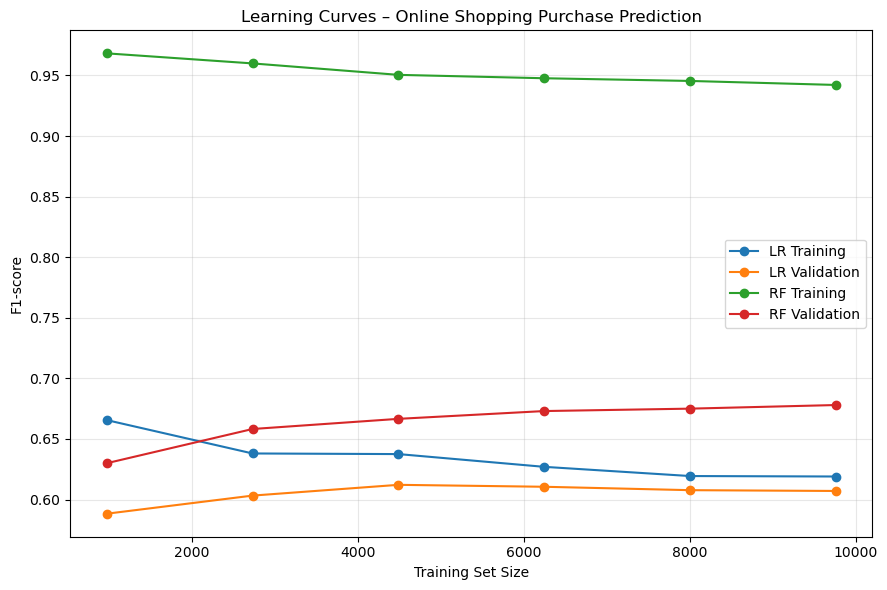

In [77]:
plt.figure(figsize=(9, 6))

plt.plot(
    shopping_lr_curve["sizes"],
    shopping_lr_curve["train_mean"],
    marker="o",
    label="LR Training"
)

plt.plot(
    shopping_lr_curve["sizes"],
    shopping_lr_curve["validation_mean"],
    marker="o",
    label="LR Validation"
)

plt.plot(
    shopping_rf_curve["sizes"],
    shopping_rf_curve["train_mean"],
    marker="o",
    label="RF Training"
)

plt.plot(
    shopping_rf_curve["sizes"],
    shopping_rf_curve["validation_mean"],
    marker="o",
    label="RF Validation"
)

plt.xlabel("Training Set Size")
plt.ylabel("F1-score")
plt.title("Learning Curves – Online Shopping Purchase Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "shopping_learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

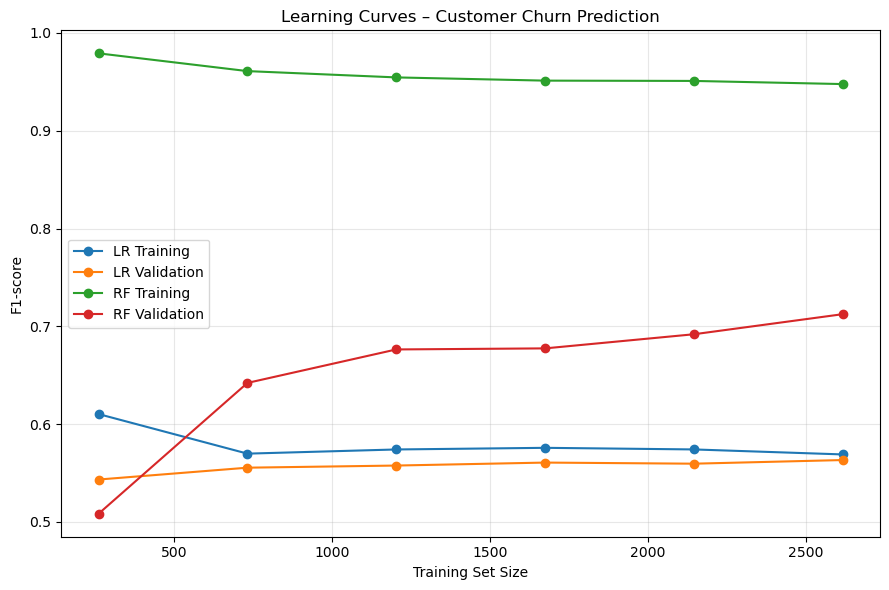

In [80]:
plt.figure(figsize=(9, 6))

plt.plot(
    churn_lr_curve["sizes"],
    churn_lr_curve["train_mean"],
    marker="o",
    label="LR Training"
)

plt.plot(
    churn_lr_curve["sizes"],
    churn_lr_curve["validation_mean"],
    marker="o",
    label="LR Validation"
)

plt.plot(
    churn_rf_curve["sizes"],
    churn_rf_curve["train_mean"],
    marker="o",
    label="RF Training"
)

plt.plot(
    churn_rf_curve["sizes"],
    churn_rf_curve["validation_mean"],
    marker="o",
    label="RF Validation"
)

plt.xlabel("Training Set Size")
plt.ylabel("F1-score")
plt.title("Learning Curves – Customer Churn Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "churn_learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
learning_curve_summary = pd.DataFrame({
    "Training Size": shopping_lr_curve["sizes"],

    "Shopping LR Train F1":
        shopping_lr_curve["train_mean"],

    "Shopping LR Validation F1":
        shopping_lr_curve["validation_mean"],

    "Shopping RF Train F1":
        shopping_rf_curve["train_mean"],

    "Shopping RF Validation F1":
        shopping_rf_curve["validation_mean"]
})

display(learning_curve_summary.round(3))


churn_learning_curve_summary = pd.DataFrame({
    "Training Size": churn_lr_curve["sizes"],

    "Churn LR Train F1":
        churn_lr_curve["train_mean"],

    "Churn LR Validation F1":
        churn_lr_curve["validation_mean"],

    "Churn RF Train F1":
        churn_rf_curve["train_mean"],

    "Churn RF Validation F1":
        churn_rf_curve["validation_mean"]
})

display(churn_learning_curve_summary.round(3))

,Training Size,Shopping LR Train F1,Shopping LR Validation F1,Shopping RF Train F1,Shopping RF Validation F1
0,976,0.666,0.588,0.968,0.630
1,2733,0.638,0.603,0.960,0.658
2,4491,0.638,0.612,0.951,0.667
3,6248,0.627,0.611,0.948,0.673
4,8006,0.619,0.608,0.945,0.675
5,9764,0.619,0.607,0.942,0.678


,Training Size,Churn LR Train F1,Churn LR Validation F1,Churn RF Train F1,Churn RF Validation F1
0,261,0.610,0.543,0.979,0.508
1,732,0.570,0.556,0.961,0.642
2,1203,0.574,0.558,0.955,0.676
3,1674,0.576,0.561,0.951,0.678
4,2145,0.574,0.560,0.951,0.692
5,2616,0.569,0.563,0.948,0.712


In [84]:
!pip install fairlearn -q


In [86]:
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Fairlearn imported successfully.")

Fairlearn imported successfully.


In [90]:
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ---------------------------------------------------------
# PART 2.3 - FAIRNESS / SUBGROUP ANALYSIS
# Online Shopping Random Forest
# Group variable: VisitorType
# ---------------------------------------------------------

# Re-create a reproducible stratified 80/20 test split
X_shop_train_fair, X_shop_test_fair, y_shop_train_fair, y_shop_test_fair = (
    train_test_split(
        X_shopping,
        y_shopping,
        test_size=0.20,
        stratify=y_shopping,
        random_state=42
    )
)

# Create a fresh copy of the existing Random Forest pipeline
shopping_rf_fair = clone(shopping_rf)

# Fit only on the training partition
shopping_rf_fair.fit(
    X_shop_train_fair,
    y_shop_train_fair
)

# Predictions on held-out test data
y_pred_fair = shopping_rf_fair.predict(X_shop_test_fair)

# Operational subgroup
visitor_groups = X_shop_test_fair["VisitorType"]


def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    if (fp + tn) == 0:
        return 0

    return fp / (fp + tn)


fairness_metrics = {
    "Accuracy": accuracy_score,

    "Precision": lambda y_true, y_pred:
        precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

    "Recall_TPR": lambda y_true, y_pred:
        recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

    "F1": lambda y_true, y_pred:
        f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

    "Selection_Rate": selection_rate,

    "False_Positive_Rate": false_positive_rate
}


metric_frame = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_shop_test_fair,
    y_pred=y_pred_fair,
    sensitive_features=visitor_groups
)

print("Overall Random Forest Performance")
display(
    pd.Series(metric_frame.overall)
      .to_frame("Overall")
      .round(3)
)

print("\nPerformance by VisitorType")
display(
    metric_frame.by_group.round(3)
)

Overall Random Forest Performance


,Overall
Accuracy,0.898
Precision,0.674
Recall_TPR,0.678
F1,0.676
Selection_Rate,0.157
False_Positive_Rate,0.061



Performance by VisitorType


,Accuracy,Precision,Recall_TPR,F1,Selection_Rate,False_Positive_Rate
VisitorType,,,,,,
New_Visitor,0.907,0.892,0.763,0.822,0.241,0.036
Other,0.923,0.000,0.000,0.000,0.077,0.077
Returning_Visitor,0.897,0.617,0.649,0.632,0.144,0.064


In [92]:

group_sample_summary = pd.DataFrame({
    "Test Samples":
        visitor_groups.value_counts(),

    "Actual Purchases":
        y_shop_test_fair.groupby(visitor_groups).sum()
})

group_sample_summary["Purchase Rate"] = (
    group_sample_summary["Actual Purchases"]
    / group_sample_summary["Test Samples"]
)

display(
    group_sample_summary.round(3)
)

,Test Samples,Actual Purchases,Purchase Rate
VisitorType,,,
New_Visitor,344,97,0.282
Other,13,0,0.000
Returning_Visitor,2084,285,0.137


In [94]:
# ---------------------------------------------------------
# DIFFERENCE BETWEEN GROUP METRICS
# ---------------------------------------------------------

group_results = metric_frame.by_group

disparity_summary = pd.DataFrame({
    "Maximum": group_results.max(),
    "Minimum": group_results.min(),
    "Difference": (
        group_results.max()
        - group_results.min()
    )
})

display(
    disparity_summary.round(3)
)

,Maximum,Minimum,Difference
Accuracy,0.923,0.897,0.026
Precision,0.892,0.000,0.892
Recall_TPR,0.763,0.000,0.763
F1,0.822,0.000,0.822
Selection_Rate,0.241,0.077,0.164
False_Positive_Rate,0.077,0.036,0.040


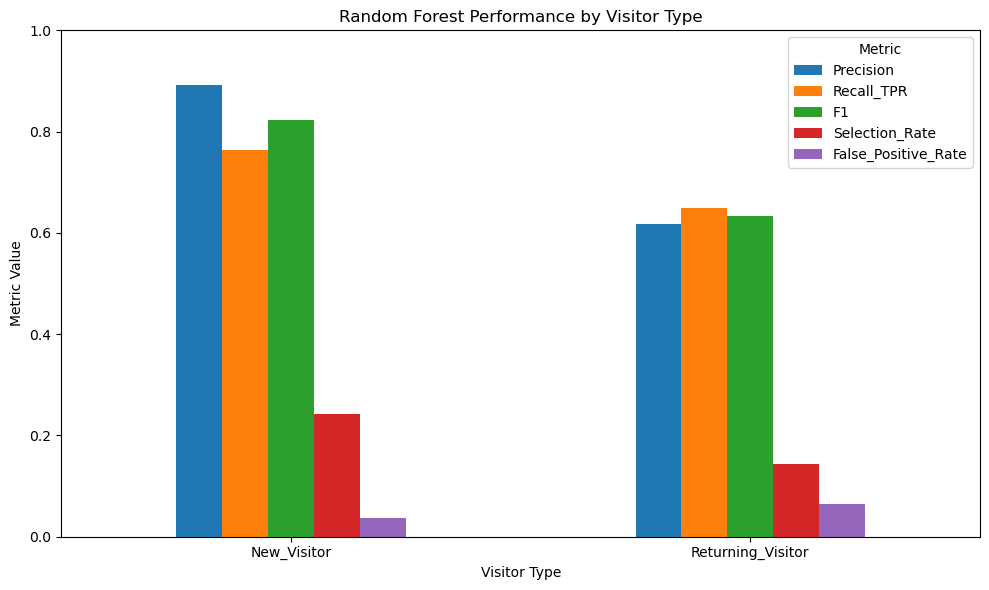

In [96]:
# ---------------------------------------------------------
# FAIRNESS / SUBGROUP PERFORMANCE FIGURE
# ---------------------------------------------------------

# Exclude "Other" from the visual comparison because the group
# contains only 13 test observations and zero positive cases.
fairness_plot = metric_frame.by_group.loc[
    ["New_Visitor", "Returning_Visitor"],
    ["Precision", "Recall_TPR", "F1",
     "Selection_Rate", "False_Positive_Rate"]
]

ax = fairness_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Random Forest Performance by Visitor Type"
)
plt.xlabel("Visitor Type")
plt.ylabel("Metric Value")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    "shopping_fairness_by_visitor_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()